In [19]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [20]:
df = pd.read_csv('diabetes.csv')

In [21]:
# features
X = df.drop('Outcome', axis=1)

In [22]:
# target
y = df['Outcome']

In [23]:
# Shapes
print('Features Shape:', X.shape)
print('Target Shape:', y.shape)

Features Shape: (768, 8)
Target Shape: (768,)


In [24]:
# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [25]:
# verify split
print('Training Features:', X_train.shape)
print('Testing Features:', X_test.shape)

print('Traing Target:', y_train.shape)
print('Testing Target:', y_test.shape)

Training Features: (614, 8)
Testing Features: (154, 8)
Traing Target: (614,)
Testing Target: (154,)


In [26]:
# standardize features
scaler = StandardScaler()

In [27]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [28]:
# results
print(X_train_scaled[:5])

[[-0.85135507 -0.98013068 -0.40478372 -0.55397256 -0.33131928 -0.60767846
   0.31079384 -0.79216928]
 [ 0.35657564  0.16144422  0.46536842  0.392787   -0.52639809 -0.30213902
  -0.11643851  0.56103382]
 [-0.5493724  -0.50447447 -0.62232176  1.21331196  0.14244354  0.3725939
  -0.76486207 -0.70759409]
 [-0.85135507  0.7956525  -0.73109078 -1.31138021 -0.73076636 -0.28940821
   0.26231357 -0.36929331]
 [-1.15333775 -0.82157861 -0.29601471  1.15019465  0.24462767  1.60748245
  -0.33762972 -0.96131967]]


In [29]:
joblib.dump(scaler, 'diabetes_scaler.pkl')

['diabetes_scaler.pkl']

In [30]:
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
classification_report
)

In [31]:
log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [32]:
# predictions
log_pred = log_model.predict(X_test_scaled)

In [33]:
# evaluate
print('Accuracy:',
     accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

Accuracy: 0.7142857142857143
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



In [34]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print('Accuracy:',
      accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Accuracy: 0.7272727272727273
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       100
           1       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154



In [35]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print('Accuracy:',
      accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.7597402597402597
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



In [36]:
svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

print('Accuracy:',
      accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

Accuracy: 0.7532467532467533
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [38]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print('Accuracy:',
      accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

Accuracy: 0.7012987012987013
              precision    recall  f1-score   support

           0       0.75      0.80      0.78       100
           1       0.58      0.52      0.55        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



In [39]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print('Accuracy:',
      accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

Accuracy: 0.7337662337662337
              precision    recall  f1-score   support

           0       0.79      0.80      0.80       100
           1       0.62      0.61      0.62        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



In [69]:
results = {
    'Logistic Regression': accuracy_score(y_test, log_pred),
    'Decision Tree': accuracy_score(y_test, dt_pred),
    'Random Forest': accuracy_score(y_test, rf_pred),
    'SVM': accuracy_score(y_test, svm_pred),
    'KNN': accuracy_score(y_test, knn_pred),
    'XGBoost': accuracy_score(y_test, xgb_pred)
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.7143
Decision Tree: 0.7273
Random Forest: 0.7597
SVM: 0.7532
KNN: 0.7013
XGBoost: 0.7338


In [70]:
best_model = max(results, key=results.get)

print('Best Model:', best_model)

Best Model: Random Forest


In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

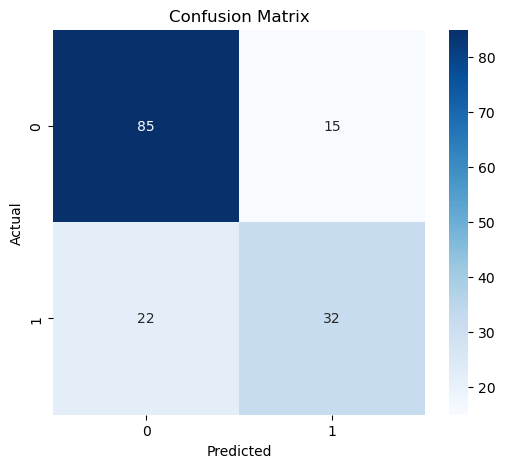

In [49]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



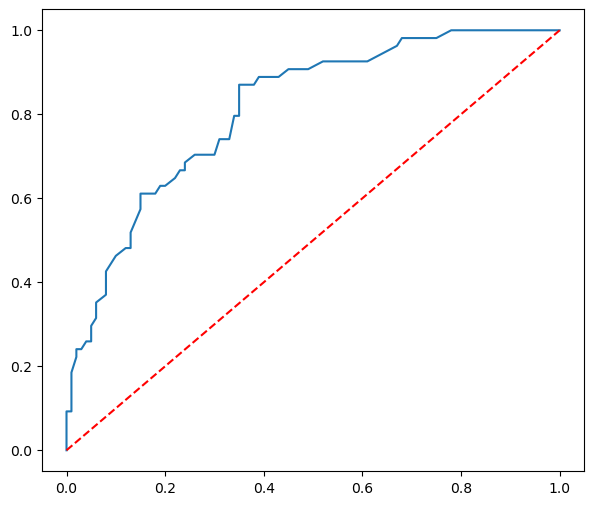

In [71]:
from sklearn.metrics import roc_curve, auc

y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')

plt.plot([0,1], [0,1], 'r--')

In [72]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)

print('AUC Score:', auc_score)

AUC Score: 0.8117592592592593


In [73]:
# cross validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores)
print('Average Accuracy:', scores.mean())

[0.74025974 0.74675325 0.75974026 0.83660131 0.75163399]
Average Accuracy: 0.7669977081741788


In [74]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                    Feature  Importance
1                   Glucose    0.276009
5                       BMI    0.159544
7                       Age    0.127248
6  DiabetesPedigreeFunction    0.126731
2             BloodPressure    0.085606
0               Pregnancies    0.084456
4                   Insulin    0.072409
3             SkinThickness    0.067997


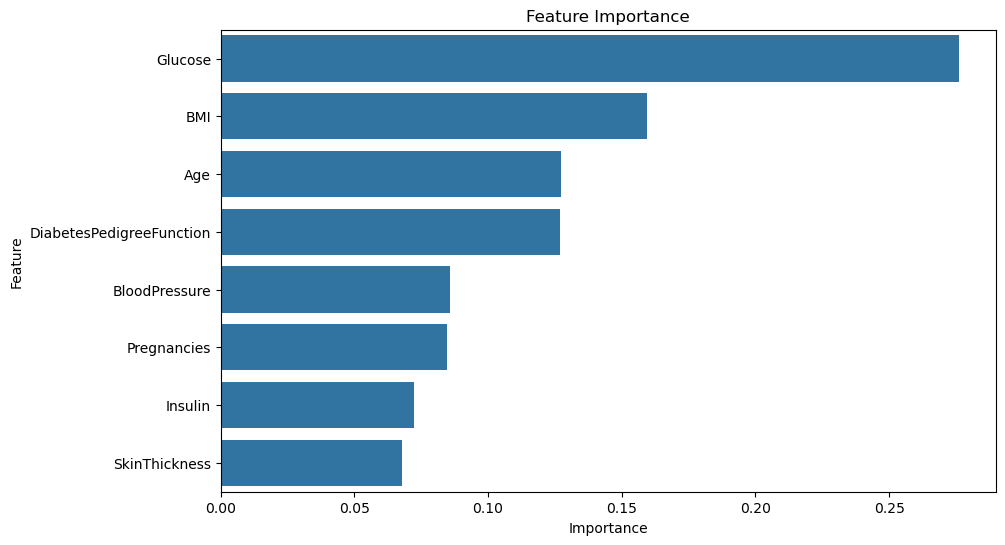

In [57]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')
plt.show()

In [60]:
joblib.dump(rf_model, 'Diabetes_Model.pkl')

['Diabetes_Model.pkl']

In [62]:
# predictions for all records
predictions = rf_model.predict(X)

In [63]:
probabilities = rf_model.predict_proba(X)[:, 1]

In [64]:
df['Predicted_Outcome'] = predictions
df['Prediction_Probability'] = probabilities

In [65]:
def risk_level(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.70:
        return "Medium Risk"
    else:
        return "High Risk"

df['Risk_Level'] = df['Prediction_Probability'].apply(risk_level)

In [66]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Predicted_Outcome,Prediction_Probability,Risk_Level
0,6,148,72,35,0,33.6,0.627,50,1,1,0.83,High Risk
1,1,85,66,29,0,26.6,0.351,31,0,0,0.01,Low Risk
2,8,183,64,0,0,23.3,0.672,32,1,1,0.96,High Risk
3,1,89,66,23,94,28.1,0.167,21,0,0,0.00,Low Risk
4,0,137,40,35,168,43.1,2.288,33,1,1,0.88,High Risk


In [67]:
df.to_csv('Diabetes_Predictions.csv', index=False)